E1

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


dataset_path = "/content/wdbc.data"


try:
    df = pd.read_csv(dataset_path, header=None)
except FileNotFoundError:
    print(f"Error: The file at '{dataset_path}' was not found. Please check the path and try again.")
    exit()
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    exit()

df = df.drop(0, axis=1)

if df.shape[1] == 32:
    if df[32].isnull().all():
        df = df.drop(32, axis=1)

y = df[1].map({'M': 1, 'B': 0})
X = df.drop(1, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Dataset loaded and split successfully.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


model = GaussianNB()
model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Dataset loaded and split successfully.
Training set size: 398 samples
Testing set size: 171 samples
Gaussian Naive Bayes model trained successfully.


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions for class labels (y_pred) and probabilities (y_prob) generated successfully.")

Predictions for class labels (y_pred) and probabilities (y_prob) generated successfully.


Accuracy Score: 0.9357

Confusion Matrix:
[[106   1]
 [ 10  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       107
           1       0.98      0.84      0.91        64

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



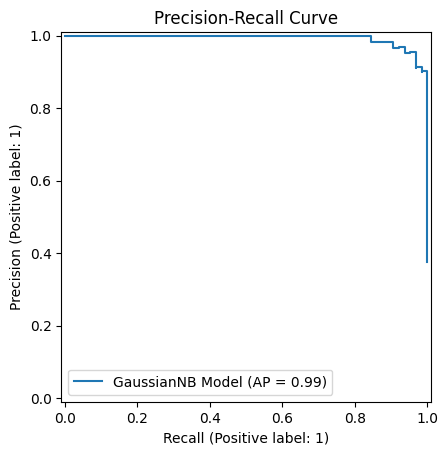

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 1. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# 2. Calculate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# 3. Generate and print the classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# 4. Calculate precision and recall values for the curve
prec, recall, _ = precision_recall_curve(y_test, y_prob)

# 5. Create a Precision-Recall display
disp = PrecisionRecallDisplay.from_predictions(y_test, y_prob, name="GaussianNB Model")

# 6. Add a title to the plot
disp.ax_.set_title('Precision-Recall Curve')

# 7. Display the plot
plt.show()


E2

In [8]:
from sklearn.svm import SVC

# Initialize the SVM classifier with probability=True
svm_model = SVC(probability=True, random_state=42)

# Train the SVM model on the training data
svm_model.fit(X_train, y_train)

print("SVM classifier trained successfully.")

SVM classifier trained successfully.


In [9]:
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class (1)

print("SVM predictions (y_pred_svm) and probabilities (y_prob_svm) generated successfully.")

SVM predictions (y_pred_svm) and probabilities (y_prob_svm) generated successfully.


SVM Accuracy Score: 0.9006

SVM Confusion Matrix:
[[107   0]
 [ 17  47]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       107
           1       1.00      0.73      0.85        64

    accuracy                           0.90       171
   macro avg       0.93      0.87      0.89       171
weighted avg       0.91      0.90      0.90       171



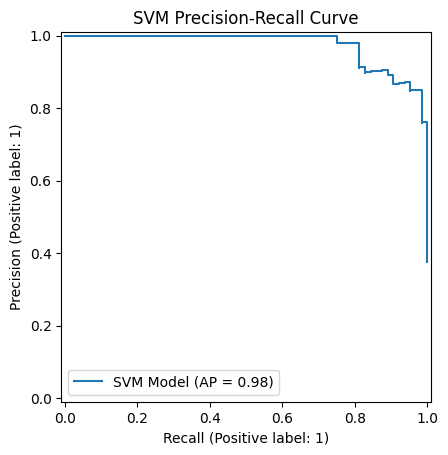

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 1. Calculate and print the accuracy score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy Score: {accuracy_svm:.4f}")

# 2. Calculate and print the confusion matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("\nSVM Confusion Matrix:")
print(conf_matrix_svm)

# 3. Generate and print the classification report
class_report_svm = classification_report(y_test, y_pred_svm)
print("\nSVM Classification Report:")
print(class_report_svm)

# 4. Calculate precision and recall values for the curve
prec_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)

# 5. Create a Precision-Recall display
disp_svm = PrecisionRecallDisplay.from_predictions(y_test, y_prob_svm, name="SVM Model")

# 6. Add a title to the plot
disp_svm.ax_.set_title('SVM Precision-Recall Curve')

# 7. Display the plot
plt.show()

In [11]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate a DecisionTreeClassifier object with a random_state for reproducibility
dtc_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model on the training data
dtc_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [12]:
y_pred_dtc = dtc_model.predict(X_test)
y_prob_dtc = dtc_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class (1)

print("Decision Tree predictions (y_pred_dtc) and probabilities (y_prob_dtc) generated successfully.")

Decision Tree predictions (y_pred_dtc) and probabilities (y_prob_dtc) generated successfully.


Decision Tree Accuracy Score: 0.9006

Decision Tree Confusion Matrix:
[[100   7]
 [ 10  54]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       107
           1       0.89      0.84      0.86        64

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



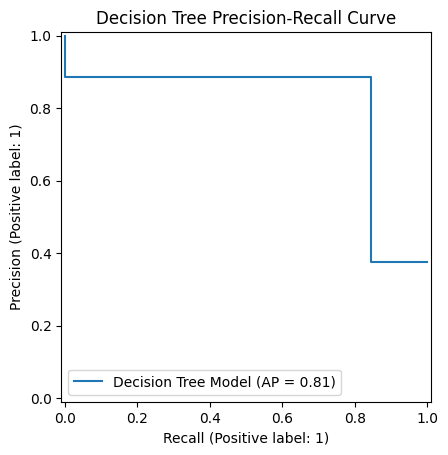

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 1. Calculate and print the accuracy score
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"Decision Tree Accuracy Score: {accuracy_dtc:.4f}")

# 2. Calculate and print the confusion matrix
conf_matrix_dtc = confusion_matrix(y_test, y_pred_dtc)
print("\nDecision Tree Confusion Matrix:")
print(conf_matrix_dtc)

# 3. Generate and print the classification report
class_report_dtc = classification_report(y_test, y_pred_dtc)
print("\nDecision Tree Classification Report:")
print(class_report_dtc)

# 4. Calculate precision and recall values for the curve
prec_dtc, recall_dtc, _ = precision_recall_curve(y_test, y_prob_dtc)

# 5. Create a Precision-Recall display
disp_dtc = PrecisionRecallDisplay.from_predictions(y_test, y_prob_dtc, name="Decision Tree Model")

# 6. Add a title to the plot
disp_dtc.ax_.set_title('Decision Tree Precision-Recall Curve')

# 7. Display the plot
plt.show()

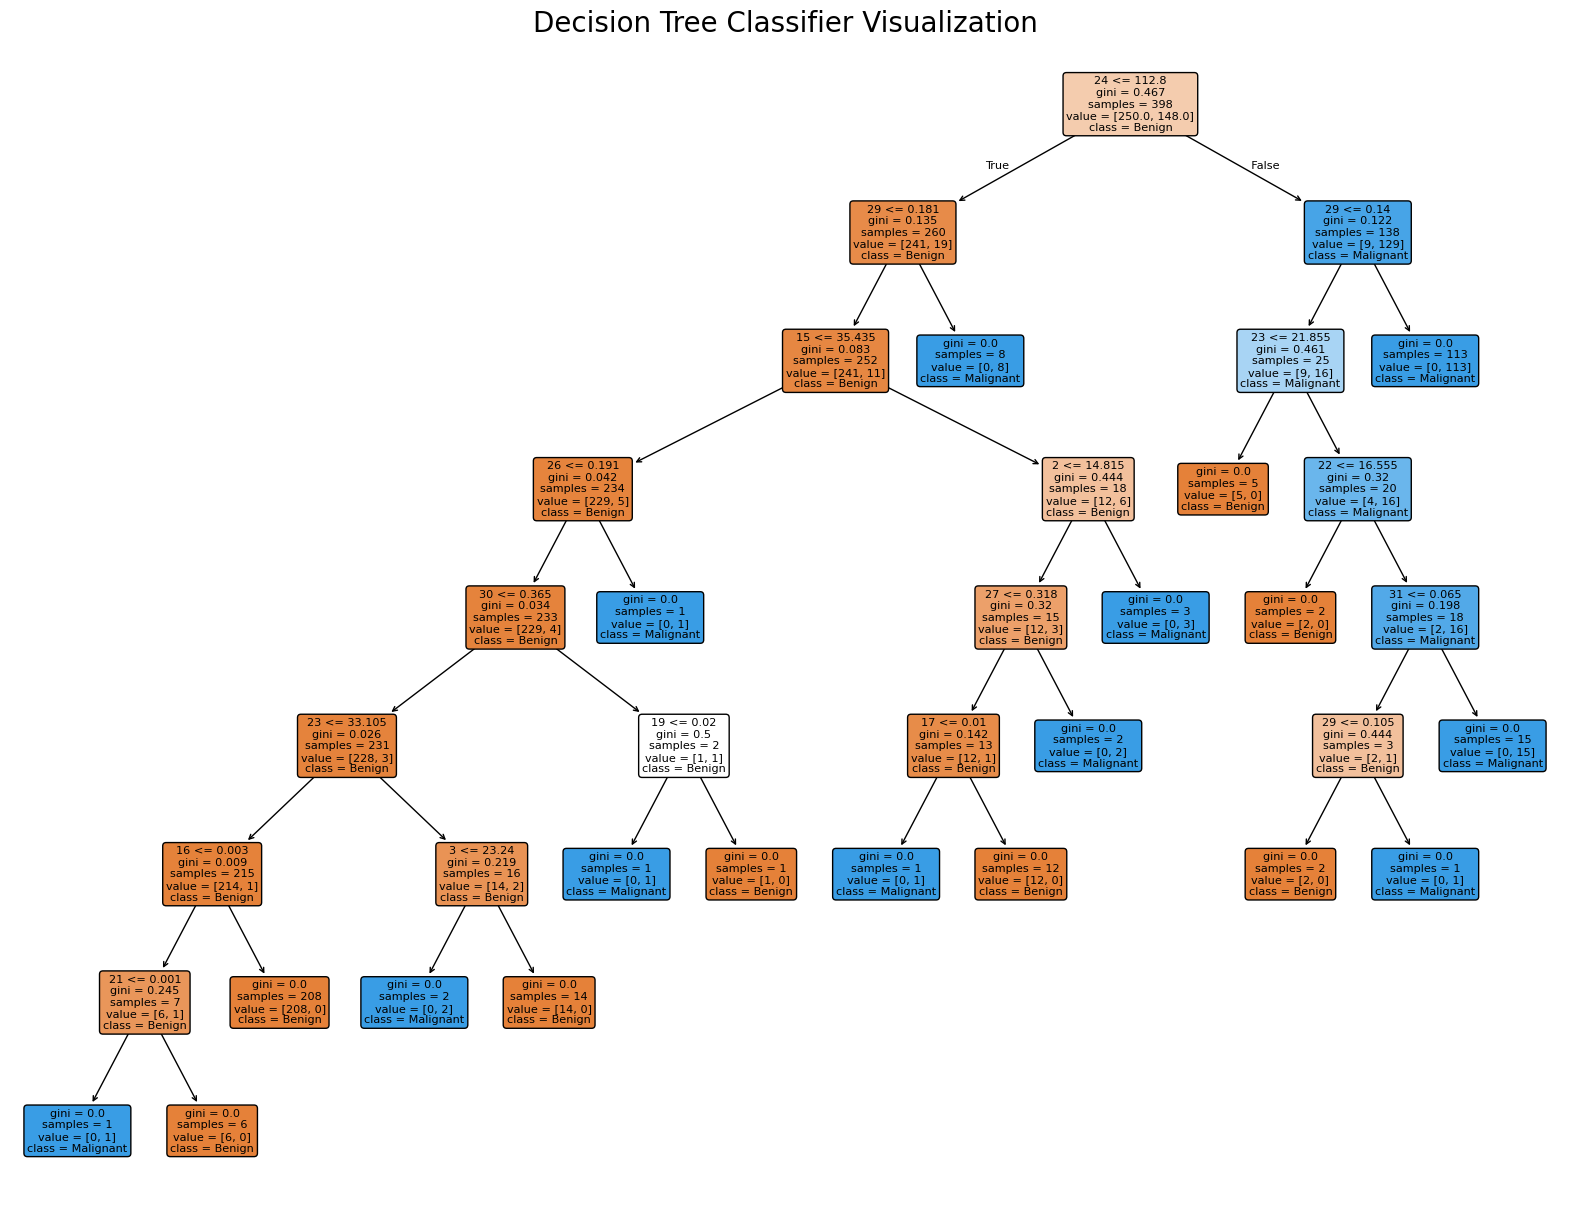

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
plt.figure(figsize=(20, 15)) # Adjust figure size for better readability

# Use plot_tree to visualize the dtc_model
plot_tree(dtc_model,
          filled=True,
          rounded=True,
          feature_names=X.columns,
          class_names=['Benign', 'Malignant'])

# Add a title to the plot
plt.title('Decision Tree Classifier Visualization', fontsize=20)

# Display the plot
plt.show()

E3

In [15]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier with n_neighbors=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model on the training data
knn_model.fit(X_train, y_train)

# Calculate the training accuracy
knn_train_accuracy = knn_model.score(X_train, y_train)

print(f"KNN classifier trained successfully.\nTraining Accuracy: {knn_train_accuracy:.4f}")

KNN classifier trained successfully.
Training Accuracy: 0.9422


In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Use the trained knn_model to make predictions on X_test
y_pred_knn = knn_model.predict(X_test)

# 2. Use the trained knn_model to predict probabilities for the positive class (class 1) on X_test
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# 3. Calculate the testing accuracy
knn_test_accuracy = accuracy_score(y_test, y_pred_knn)

# 4. Calculate the confusion matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# 5. Print the testing accuracy and the confusion matrix
print(f"KNN Test Accuracy: {knn_test_accuracy:.4f}")
print("\nKNN Confusion Matrix:")
print(conf_matrix_knn)

print("\nKNN predictions (y_pred_knn), probabilities (y_prob_knn), testing accuracy, and confusion matrix generated successfully.")

KNN Test Accuracy: 0.9298

KNN Confusion Matrix:
[[106   1]
 [ 11  53]]

KNN predictions (y_pred_knn), probabilities (y_prob_knn), testing accuracy, and confusion matrix generated successfully.


In [17]:
svm_train_accuracy = svm_model.score(X_train, y_train)

print(f"SVM Training Accuracy: {svm_train_accuracy:.4f}")

SVM Training Accuracy: 0.9095


In [18]:
gnb_train_accuracy = model.score(X_train, y_train)
print(f"Gaussian Naive Bayes Training Accuracy: {gnb_train_accuracy:.4f}")

Gaussian Naive Bayes Training Accuracy: 0.9497


In [19]:
dtc_train_accuracy = dtc_model.score(X_train, y_train)
print(f"Decision Tree Training Accuracy: {dtc_train_accuracy:.4f}")

Decision Tree Training Accuracy: 1.0000


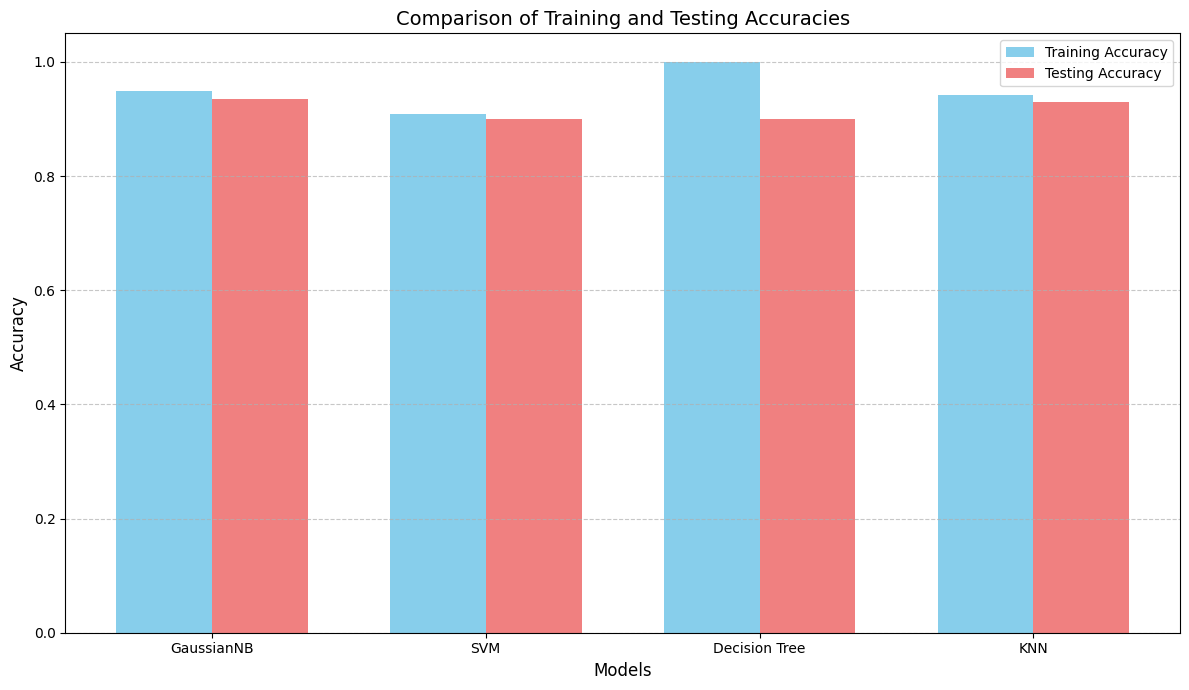

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Gather all accuracies into a dictionary
accuracies = {
    'Model': ['GaussianNB', 'SVM', 'Decision Tree', 'KNN'],
    'Training Accuracy': [
        gnb_train_accuracy,
        svm_train_accuracy,
        dtc_train_accuracy,
        knn_train_accuracy
    ],
    'Testing Accuracy': [
        accuracy,
        accuracy_svm,
        accuracy_dtc,
        knn_test_accuracy
    ]
}

# Convert to DataFrame for easier plotting
df_accuracies = pd.DataFrame(accuracies)

# Set the position for the bars
bar_width = 0.35
index = range(len(df_accuracies['Model']))

# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 7))

bar1 = ax.bar([i - bar_width/2 for i in index], df_accuracies['Training Accuracy'], bar_width, label='Training Accuracy', color='skyblue')
bar2 = ax.bar([i + bar_width/2 for i in index], df_accuracies['Testing Accuracy'], bar_width, label='Testing Accuracy', color='lightcoral')

# Add labels, title, and legend
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparison of Training and Testing Accuracies', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(df_accuracies['Model'], rotation=0, fontsize=10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


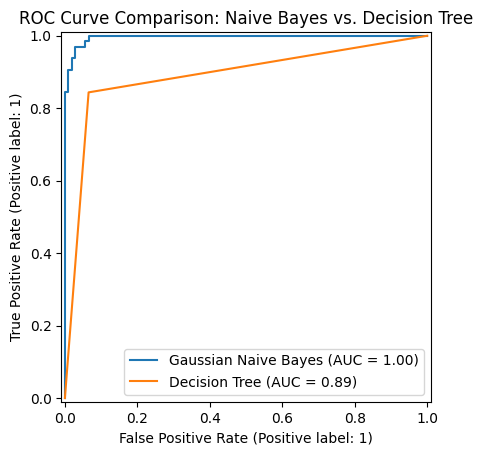

In [21]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Create the first ROC curve for the Naive Bayes model
disp_nb = RocCurveDisplay.from_predictions(y_test, y_prob, name="Gaussian Naive Bayes")

# Create the second ROC curve for the Decision Tree model on the same plot
disp_dtc = RocCurveDisplay.from_predictions(y_test, y_prob_dtc, name="Decision Tree", ax=disp_nb.ax_)

# Add a title to the plot
disp_dtc.ax_.set_title('ROC Curve Comparison: Naive Bayes vs. Decision Tree')

# Add a legend to distinguish between the two models (already handled by from_predictions with name parameter)

# Display the plot
plt.show()

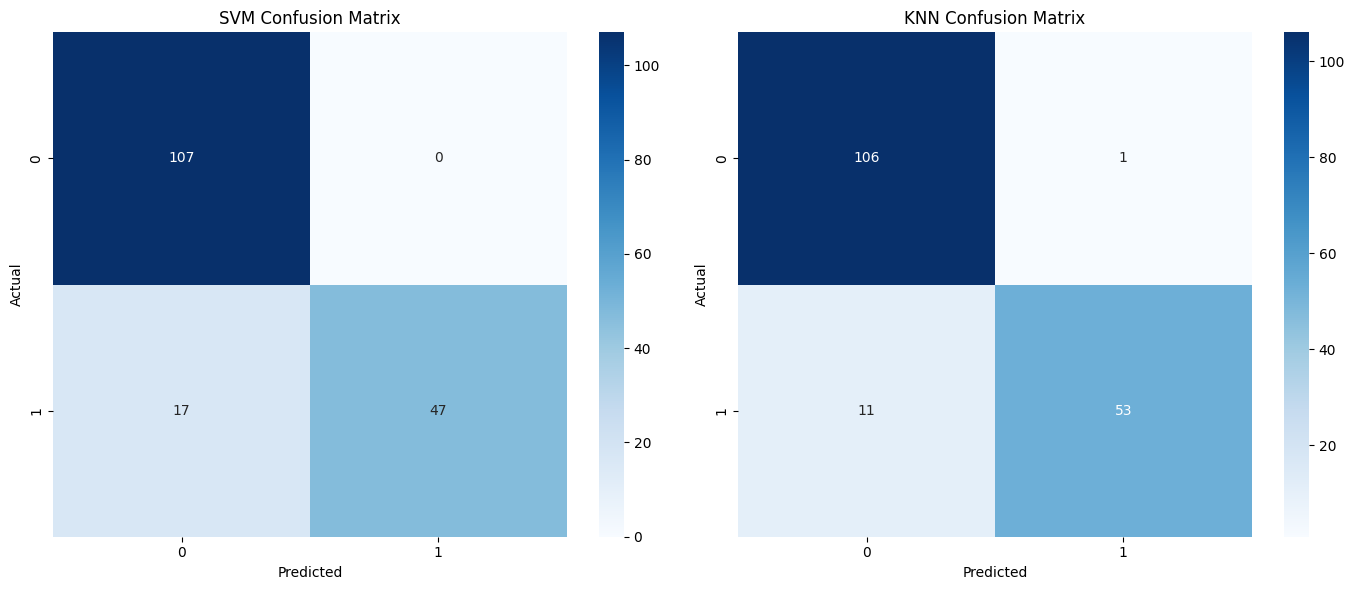

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot SVM Confusion Matrix
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('SVM Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Plot KNN Confusion Matrix
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('KNN Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
